# 📊 工程圖紙資料集 EDA 高效能 Pipeline

> 本 Notebook 為 `v2/analyze_data_notebook.ipynb` 的高效能升級版，針對 9 萬張以上影像的 IO 瓶頸與運算進行深度最佳化，利用 PyTorch DataLoader 多執行緒與 GPU 張量運算實現極速 EDA 與特徵萃取。


In [1]:
import os
import sys
import time
import math
import random
import warnings
from pathlib import Path
import concurrent.futures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import kornia
import fiftyone as fo

# 特徵分群與降維
from sklearn.ensemble import IsolationForest
import umap

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

Image.MAX_IMAGE_PIXELS = None

# 環境路徑設定
_NB_DIR = Path(os.getcwd()).resolve()
_V2_DIR = None
for _c in [_NB_DIR, _NB_DIR / 'v2', _NB_DIR.parent, _NB_DIR.parent / 'v2']:
    if (_c / 'src' / 'data').is_dir():
        _V2_DIR = _c
        break
assert _V2_DIR is not None, f'找不到 src/data 目錄'

if str(_V2_DIR) not in sys.path:
    sys.path.insert(0, str(_V2_DIR))

# 匯入自定義模組
from src.model.simsiam import SimSiam

# 設備設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_cores = os.cpu_count()
print(f"系統 CPU 核心數: {num_cores}")
print(f"目前使用計算設備: {device}")
if device.type == 'cuda':
    print(f"GPU 名稱: {torch.cuda.get_device_name(0)}")


系統 CPU 核心數: 20
目前使用計算設備: cuda
GPU 名稱: NVIDIA GeForce RTX 5090


In [2]:
# 參數設定
DATA_DIR = _V2_DIR.parent / 'data' / 'converted_images'
OUTPUT_DIR = _V2_DIR.parent / 'outputs' / 'eda_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
NUM_WORKERS = min(16, num_cores) # 充分利用多核心 CPU 進行 IO 讀取與 CPU 拓樸運算

_IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
all_images = sorted([p for p in DATA_DIR.rglob('*') if p.suffix.lower() in _IMG_EXTS])
print(f'📁 資料目錄: {DATA_DIR}')
print(f'🖼️  影像總數: {len(all_images):,}')


📁 資料目錄: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/data/converted_images
🖼️  影像總數: 94,524


In [3]:
class EngineeringDrawingDataset(Dataset):
    def __init__(self, image_paths, img_size=(224, 224)):
        self.image_paths = image_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        str_path = str(path)
        
        # 1. 嘗試讀取影像尺寸與基礎圖素
        try:
            with Image.open(str_path) as img:
                w, h = img.size
                # 轉為灰階並 Resize 以便後續卷積與特徵萃取
                img_gray = img.convert('L')
                img_resized = img_gray.resize(self.img_size)
                img_array = np.array(img_resized)
                status = "ok"
                
                # 計算拓樸特徵 (Connected Components) 於 CPU 多執行緒
                # 先二值化 (Otsu)
                _, thresh = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
                num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
                
                cc_count = num_labels - 1 # 扣除背景
                
        except Exception:
            # 處理讀取失敗 (Corrupted)
            img_array = np.zeros(self.img_size, dtype=np.uint8)
            w, h, cc_count = 0, 0, 0
            status = "corrupted"
            
        # 轉為 tensor, 加上 channel dimension
        tensor_img = torch.from_numpy(img_array).float().unsqueeze(0) / 255.0
        
        return {
            'path': str_path,
            'image': tensor_img,
            'width': w,
            'height': h,
            'cc_count': cc_count,
            'status': status
        }
        
dataset = EngineeringDrawingDataset(all_images)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)


In [4]:
def compute_image_entropy(tensor_batch, bins=256):
    B = tensor_batch.size(0)
    entropy_list = []
    for i in range(B):
        hist = torch.histc(tensor_batch[i], bins=bins, min=0, max=1)
        prob = hist / hist.sum()
        prob = prob[prob > 0]
        entropy = -torch.sum(prob * torch.log2(prob))
        entropy_list.append(entropy.item())
    return torch.tensor(entropy_list, device=tensor_batch.device)

# 實例化模型進行特徵提取 (使用 Backbone)
model = SimSiam(backbone='resnet18', pretrained=True, in_channels=1).to(device)
model.eval()

results = []

print("🚀 開始平行運算影像特徵與品質檢測...")
start_time = time.time()

with torch.no_grad():
    for batch_idx, batch in enumerate(dataloader):
        imgs = batch['image'].to(device)
        paths = batch['path']
        widths = batch['width']
        heights = batch['height']
        cc_counts = batch['cc_count']
        statuses = batch['status']
        
        B = imgs.size(0)
        
        # --- 基本品質檢測 ---
        std_devs = imgs.view(B, -1).std(dim=1)
        blank_mask = std_devs < 1e-4
        sparsity = (imgs > 0.95).float().view(B, -1).mean(dim=1)
        
        # --- FFT 高頻能量分析 ---
        fft_result = torch.fft.fft2(imgs)
        fft_shift = torch.fft.fftshift(fft_result)
        magnitude = torch.abs(fft_shift)
        
        H, W = imgs.shape[2], imgs.shape[3]
        cy, cx = H // 2, W // 2
        r = min(H, W) // 8
        y_grid, x_grid = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
        dist = (y_grid - cy)**2 + (x_grid - cx)**2
        high_freq_mask = dist > r**2
        
        total_energy = magnitude.view(B, -1).sum(dim=1)
        total_energy = torch.clamp(total_energy, min=1e-8)
        high_freq_energy = (magnitude * high_freq_mask).view(B, -1).sum(dim=1) / total_energy
        
        # --- 幾何密度 (Line-to-Edge Ratio) ---
        edges = kornia.filters.sobel(imgs)
        edge_density = (edges > 0.1).float().view(B, -1).mean(dim=1)
        
        # --- 影像資訊熵 ---
        entropies = compute_image_entropy(imgs)
        
        # --- 深層表徵萃取 (Deep Features) ---
        features = model.backbone(imgs)
        
        for i in range(B):
            stat = statuses[i]
            if stat == "ok" and blank_mask[i].item():
                stat = "blank"
                
            results.append({
                'path': paths[i],
                'width': widths[i].item(),
                'height': heights[i].item(),
                'aspect_ratio': widths[i].item() / heights[i].item() if heights[i].item() > 0 else 0,
                'status': stat,
                'cc_count': cc_counts[i].item(),
                'sparsity': sparsity[i].item(),
                'high_freq_energy': high_freq_energy[i].item() if not torch.isnan(high_freq_energy[i]) else 0.0,
                'edge_density': edge_density[i].item(),
                'entropy': entropies[i].item(),
                'feature': features[i].cpu().numpy()
            })
            
        if (batch_idx + 1) % 100 == 0:
            print(f"已處理 { (batch_idx + 1) * B } / {len(dataset)} 筆影像... 耗時: {time.time() - start_time:.2f}s")
            
print(f"✅ 處理完成! 總耗時: {time.time() - start_time:.2f}s")


[2026-04-24 19:34:28] [INFO    ] [src.model.backbone] Backbone 建立完成: resnet18 (pretrained=True, in_channels=1, feat_dim=512)
[2026-04-24 19:34:28] [INFO    ] [src.model.simsiam] SimSiam 初始化完成: total_params=14,586,304, trainable=14,586,304
🚀 開始平行運算影像特徵與品質檢測...
已處理 12800 / 94524 筆影像... 耗時: 73.73s
已處理 25600 / 94524 筆影像... 耗時: 139.20s
已處理 38400 / 94524 筆影像... 耗時: 203.71s
已處理 51200 / 94524 筆影像... 耗時: 266.37s
已處理 64000 / 94524 筆影像... 耗時: 333.74s
已處理 76800 / 94524 筆影像... 耗時: 402.57s
已處理 89600 / 94524 筆影像... 耗時: 475.74s
✅ 處理完成! 總耗時: 499.84s


In [5]:
df = pd.DataFrame(results)

# 將特徵矩陣轉為多維特徵欄位
feat_matrix = np.vstack(df['feature'].values)
feat_cols = [f'feat_{i}' for i in range(feat_matrix.shape[1])]
df_feats = pd.DataFrame(feat_matrix, columns=feat_cols)
df = pd.concat([df.drop(columns=['feature']), df_feats], axis=1)

parquet_path = OUTPUT_DIR / 'eda_features.parquet'
df.to_parquet(parquet_path, engine='pyarrow')
print(f"💾 結構化特徵與分析結果已儲存為 Parquet: {parquet_path}")

# 將正常影像與異常影像分開
df_valid = df[df['status'] == 'ok'].copy()
df_corrupted = df[df['status'] == 'corrupted'].copy()
df_blank = df[df['status'] == 'blank'].copy()

print(f"資料品質品質過濾分佈：正常 {len(df_valid)}, 損毀 {len(df_corrupted)}, 空白 {len(df_blank)}")


💾 結構化特徵與分析結果已儲存為 Parquet: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/outputs/eda_results/eda_features.parquet
資料品質品質過濾分佈：正常 94515, 損毀 0, 空白 9


In [6]:
print("🔍 進行高維特徵異常檢測 (Isolation Forest)...")
features_for_if = df_valid[feat_cols].values

# Isolation Forest 偵測異常 (假設有 5% 的離群值)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(features_for_if)
df_valid['is_outlier'] = (outliers == -1)

print(f"檢測出 {df_valid['is_outlier'].sum()} 筆潛在異常或極端樣本。")

print("🌌 進行 UMAP 降維以視覺化深層特徵空間...")
# 為了視覺化清晰度與速度，自隨機抽樣 5000 筆樣本進行 UMAP
sample_size = min(5000, len(features_for_if))
sample_indices = np.random.choice(len(features_for_if), sample_size, replace=False)
features_sample = features_for_if[sample_indices]

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(features_sample)

df_valid_sample = df_valid.iloc[sample_indices].copy()
df_valid_sample['umap_x'] = embedding[:, 0]
df_valid_sample['umap_y'] = embedding[:, 1]


🔍 進行高維特徵異常檢測 (Isolation Forest)...
檢測出 4726 筆潛在異常或極端樣本。
🌌 進行 UMAP 降維以視覺化深層特徵空間...


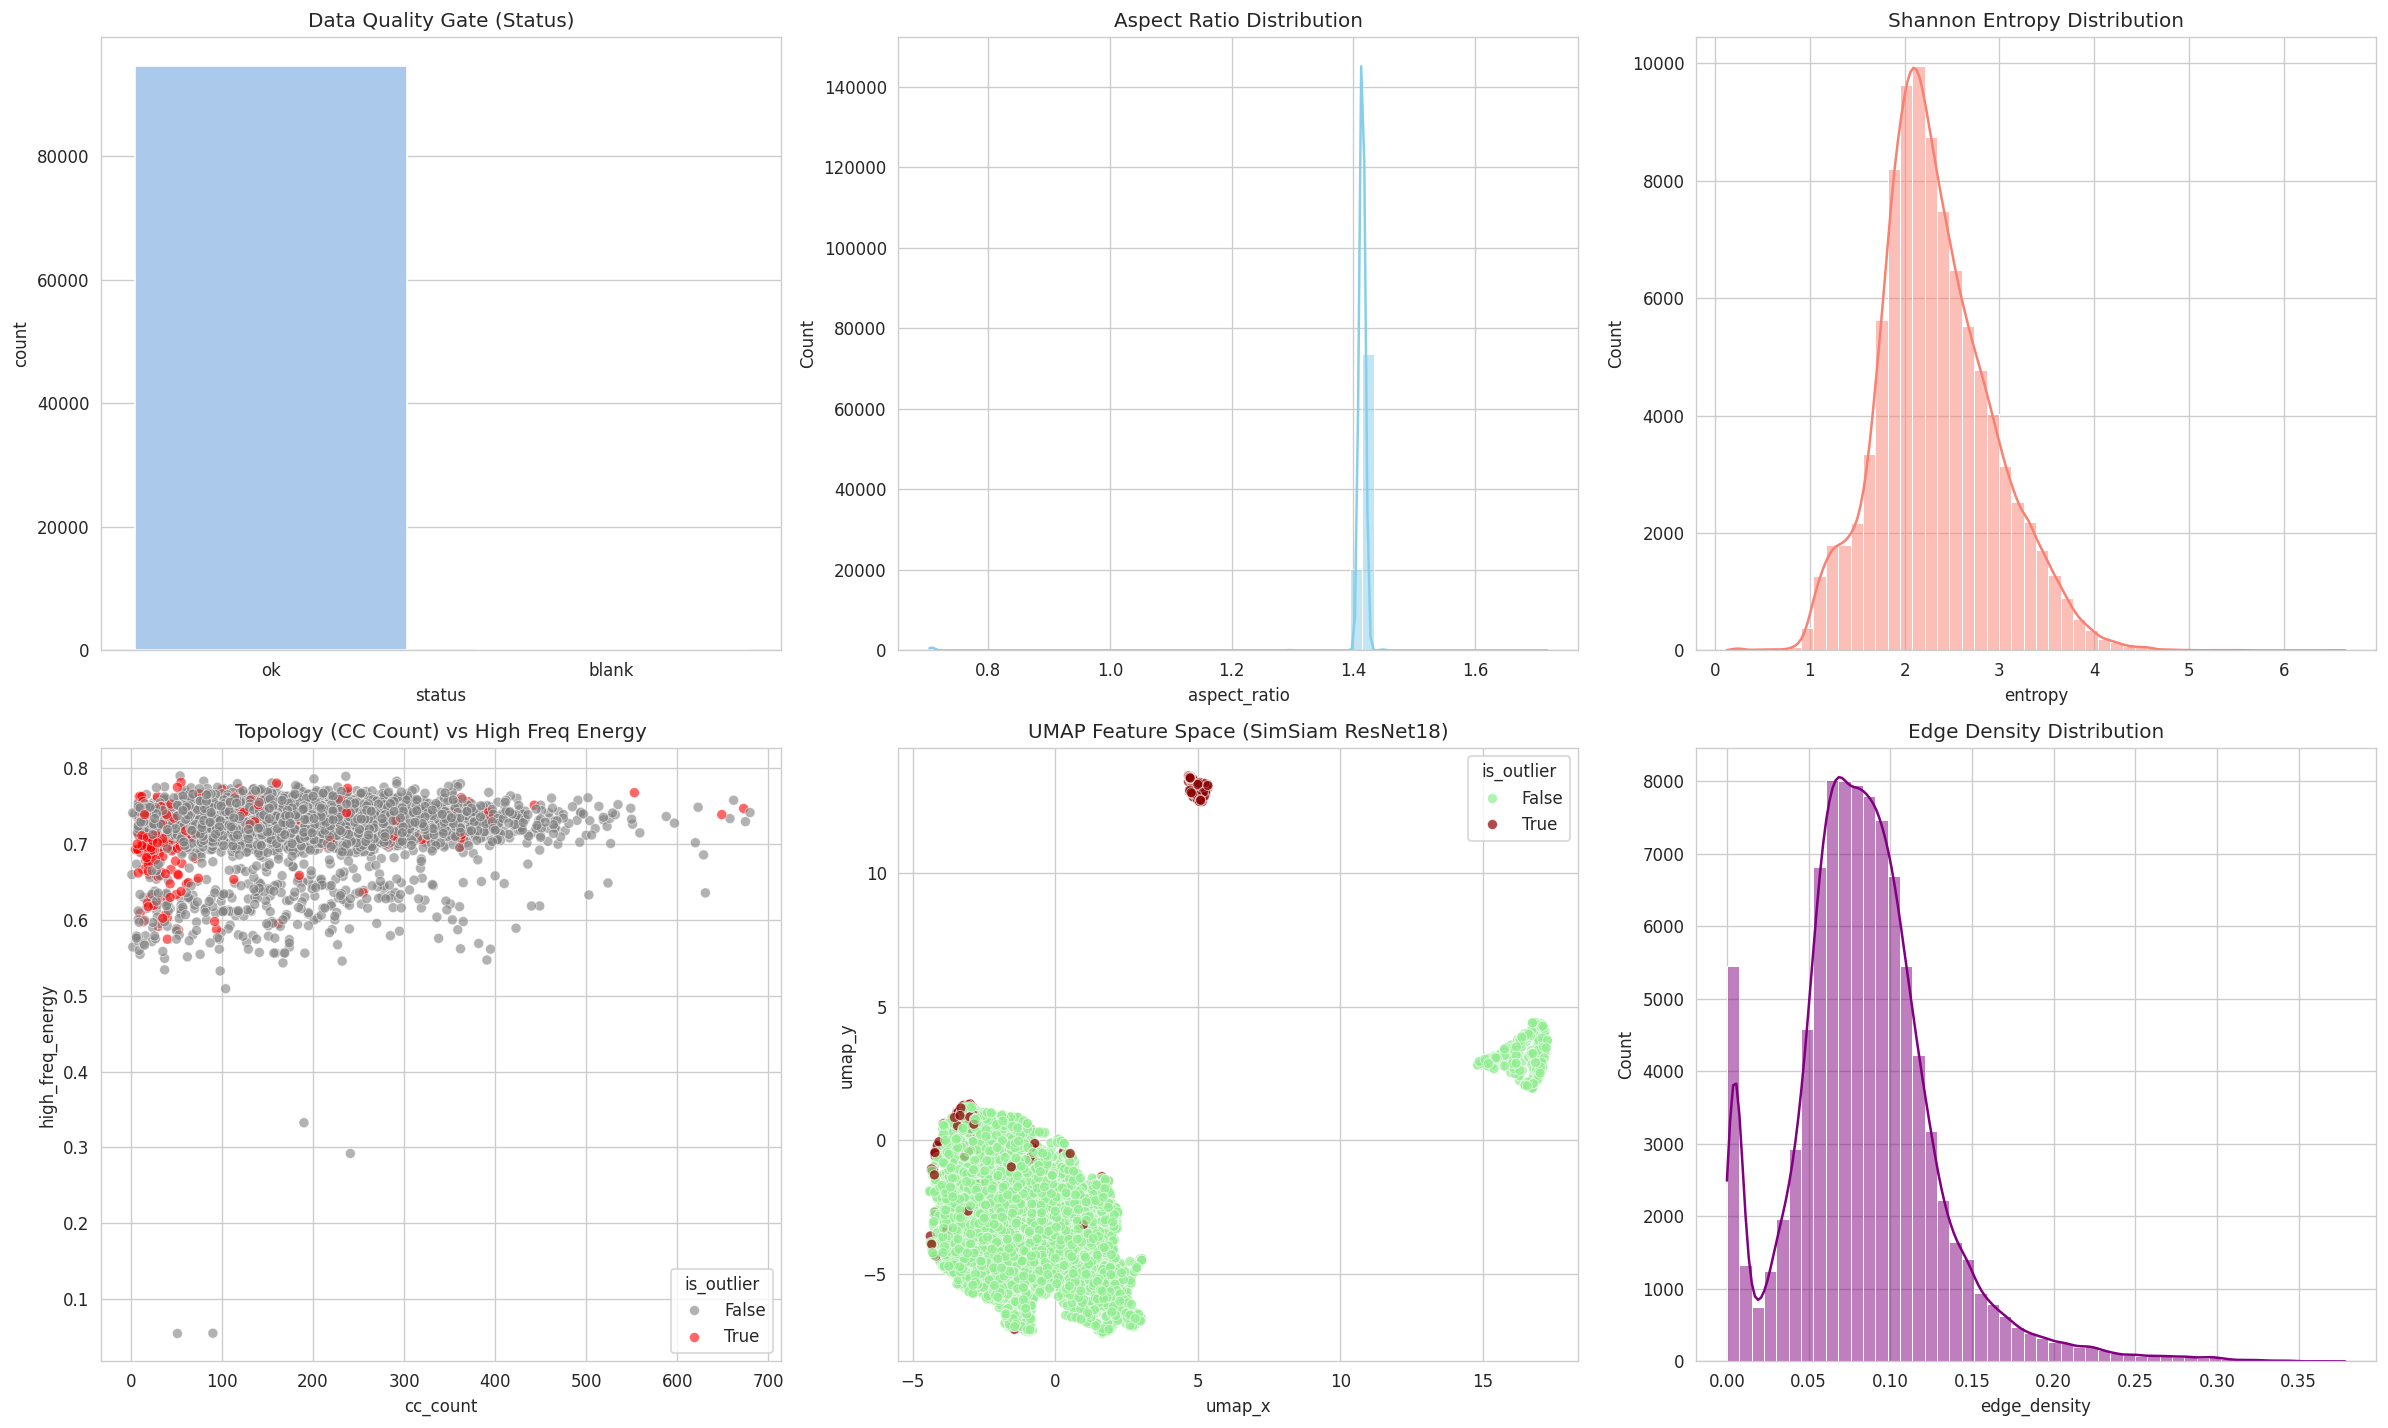

🎉 高效能 EDA Pipeline 執行完畢！綜整報告已儲存。


In [7]:
# 📊 產出 Data Profile Report 視覺化
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. 影像狀態分佈
sns.countplot(data=df, x='status', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Data Quality Gate (Status)')

# 2. 幾何長寬比分佈
sns.histplot(data=df_valid, x='aspect_ratio', bins=50, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Aspect Ratio Distribution')

# 3. 資訊熵分佈 (Image Entropy)
sns.histplot(data=df_valid, x='entropy', bins=50, kde=True, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Shannon Entropy Distribution')

# 4. 高頻能量 vs 連通域數量散點圖
sns.scatterplot(data=df_valid_sample, x='cc_count', y='high_freq_energy', 
                hue='is_outlier', palette={False: 'gray', True: 'red'}, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Topology (CC Count) vs High Freq Energy')

# 5. UMAP 異常投影 (自監督表徵)
sns.scatterplot(data=df_valid_sample, x='umap_x', y='umap_y', 
                hue='is_outlier', palette={False: 'lightgreen', True: 'darkred'}, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('UMAP Feature Space (SimSiam ResNet18)')

# 6. 幾何密度 (Edge Density) 分佈
sns.histplot(data=df_valid, x='edge_density', bins=50, kde=True, ax=axes[1, 2], color='purple')
axes[1, 2].set_title('Edge Density Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_profile_report.png', dpi=300)
plt.show()

print("🎉 高效能 EDA Pipeline 執行完畢！綜整報告已儲存。")


## 9. 離群值 (Outliers) 互動式檢視 (FiftyOne)

> 為了避免巨量圖片直接渲染造成 Jupyter Notebook / 瀏覽器卡頓甚至崩潰，我們引入了 **FiftyOne** 函式庫。
> 我們將所有正常讀取的影像與剛才計算出的分析指標 (Metric) 建立成 FiftyOne Dataset，並對被判定為極端離群值的影像打上 Tag。
> 您可以在下方的互動式 App 中直接過濾 Tag 或針對指標進行排序，以最高效的方式探索 9 萬張影像。


In [8]:
# 計算極端值的閾值
df_analysis = df_valid[df_valid['status'] == 'ok'].copy()

ar_upper = df_analysis['aspect_ratio'].quantile(0.995)
ar_lower = df_analysis['aspect_ratio'].quantile(0.005)
ent_lower = df_analysis['entropy'].quantile(0.01)
spa_upper = df_analysis['sparsity'].quantile(0.99)
hfe_upper = df_analysis['high_freq_energy'].quantile(0.995)
cc_upper = df_analysis['cc_count'].quantile(0.995)

# 建立或載入 FiftyOne Dataset
dataset_name = "engineering_drawings_eda"
if fo.dataset_exists(dataset_name):
    print(f"📦 發現已存在的 FiftyOne 資料集 '{dataset_name}'，直接載入以保留手動標籤！")
    dataset = fo.load_dataset(dataset_name)
    # 若需重新建立，請手動執行 fo.delete_dataset(dataset_name)
else:
    print("📦 正在建立全新的 FiftyOne 資料集並設定為持久化 (Persistent)...")
    dataset = fo.Dataset(name=dataset_name)
    dataset.persistent = True  # 設定持久化，讓手動標籤不會消失

samples = []
for idx, row in df_analysis.iterrows():
    # FiftyOne Sample 需要絕對或相對的檔案路徑
    sample = fo.Sample(filepath=str(row['path']))
    
    # 寫入分析指標
    sample["aspect_ratio"] = float(row["aspect_ratio"])
    sample["cc_count"] = int(row["cc_count"])
    sample["high_freq_energy"] = float(row["high_freq_energy"])
    sample["entropy"] = float(row["entropy"])
    sample["edge_density"] = float(row["edge_density"])
    sample["sparsity"] = float(row["sparsity"])
    sample["is_outlier"] = bool(row["is_outlier"])
    
    # 根據閾值為極端樣本打上 Tag
    tags = []
    if row["aspect_ratio"] > ar_upper or row["aspect_ratio"] < ar_lower:
        tags.append("extreme_aspect_ratio")
    if row["entropy"] < ent_lower:
        tags.append("low_entropy")
    if row["sparsity"] > spa_upper:
        tags.append("high_sparsity")
    if row["high_freq_energy"] > hfe_upper:
        tags.append("high_freq_energy")
    if row["cc_count"] > cc_upper:
        tags.append("high_cc_count")
    if row["is_outlier"]:
        tags.append("simsiam_outlier")
        
    if tags:
        sample.tags = tags
        
    samples.append(sample)

# 批次新增至資料集
dataset.add_samples(samples)
print(f"✅ 成功載入 {len(dataset)} 筆影像至 FiftyOne 資料集。")


📦 發現已存在的 FiftyOne 資料集 'engineering_drawings_eda'，直接載入以保留手動標籤！
 100% |█████████████| 94515/94515 [9.3s elapsed, 0s remaining, 11.0K samples/s]      
[2026-04-24 19:43:24] [INFO    ] [eta.core.utils]  100% |█████████████| 94515/94515 [9.3s elapsed, 0s remaining, 11.0K samples/s]      
✅ 成功載入 283545 筆影像至 FiftyOne 資料集。


In [9]:
# 🚀 啟動 FiftyOne 互動式介面
print("⚠️ 由於遠端伺服器 (Docker/SSH) 限制，Notebook 內嵌畫面可能無法渲染。")
print("我們將在背景指定通訊埠啟動，請直接使用瀏覽器開啟！")

# 指定 address 為 0.0.0.0 並指定 port 5151
try:
    if 'session' in locals() and session is not None:
        session.close()
except:
    pass

session = fo.launch_app(dataset, address="127.0.0.1", port=5151, auto=False)

print("\n" + "="*60)
print("✅ FiftyOne App 已成功啟動！")
print("👉 請在您的本地電腦瀏覽器輸入以下網址開啟：")
print("🌐 http://127.0.0.1:5151")
print("="*60 + "\n")
print("(如果 VSCode 右下角有跳出「埠已轉發 (Port forwarded)」的通知，請直接點選開啟)")

# 保持運行直到手動停止
session.wait()



⚠️ 由於遠端伺服器 (Docker/SSH) 限制，Notebook 內嵌畫面可能無法渲染。
我們將在背景指定通訊埠啟動，請直接使用瀏覽器開啟！
Session launched. Run `session.show()` to open the App in a cell output.
[2026-04-24 19:43:40] [INFO    ] [fiftyone.core.session.session] Session launched. Run `session.show()` to open the App in a cell output.

✅ FiftyOne App 已成功啟動！
👉 請在您的本地電腦瀏覽器輸入以下網址開啟：
🌐 http://127.0.0.1:5151

(如果 VSCode 右下角有跳出「埠已轉發 (Port forwarded)」的通知，請直接點選開啟)
Notebook sessions cannot wait
[2026-04-24 19:43:40] [WARNING ] [fiftyone.core.session.session] Notebook sessions cannot wait


## 10. 手動標籤持久化與匯出 (Export Manual Tags)

> 由於我們已將 FiftyOne 資料集設定為 `persistent = True`，您在 UI 介面上手動打上的標籤 (例如：`bad_scan`, `to_delete`) 將會被永久保存在資料庫中。
> 下方的程式碼可以讓您隨時將這些標籤匯出為 CSV，方便後續在 ML Pipeline 中直接作為黑名單或過濾清單使用！


In [10]:
# 取得目前資料集中所有的 Tags
all_tags = dataset.distinct("tags")
print("🎯 目前資料集中存在的所有標籤：", all_tags)

# 掃描所有影像，將有標籤的影像匯出為 DataFrame
tag_records = []
for sample in dataset.iter_samples():
    if sample.tags:
        tag_records.append({
            "path": sample.filepath,
            "tags": ",".join(sample.tags) # 將標籤轉為字串格式
        })

if tag_records:
    df_tags = pd.DataFrame(tag_records)
    export_path = OUTPUT_DIR / 'manual_tags.csv'
    df_tags.to_csv(export_path, index=False)
    print(f"\n✅ 已成功匯出 {len(df_tags)} 筆包含標籤的資料至: {export_path}")
    display(df_tags.head(10))
else:
    print("\nℹ️ 目前沒有任何影像包含標籤。")


🎯 目前資料集中存在的所有標籤： ['extreme_aspect_ratio', 'high_cc_count', 'high_freq_energy', 'high_sparsity', 'low_entropy', 'simsiam_outlier']

✅ 已成功匯出 21333 筆包含標籤的資料至: /home/master-user/Desktop/Engineering_Image_Retrieval_System_Training/outputs/eda_results/manual_tags.csv


,path,tags
0,/home/master-user/Desktop/Engineering_Image_Re...,extreme_aspect_ratio
1,/home/master-user/Desktop/Engineering_Image_Re...,extreme_aspect_ratio
2,/home/master-user/Desktop/Engineering_Image_Re...,low_entropy
3,/home/master-user/Desktop/Engineering_Image_Re...,low_entropy
4,/home/master-user/Desktop/Engineering_Image_Re...,low_entropy
5,/home/master-user/Desktop/Engineering_Image_Re...,extreme_aspect_ratio
6,/home/master-user/Desktop/Engineering_Image_Re...,extreme_aspect_ratio
7,/home/master-user/Desktop/Engineering_Image_Re...,simsiam_outlier
8,/home/master-user/Desktop/Engineering_Image_Re...,simsiam_outlier
9,/home/master-user/Desktop/Engineering_Image_Re...,simsiam_outlier
